# Level Zero

## Imports

In [1]:
import scipy.io as sio
import numpy as np
from collections import deque
import heapq
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

## Preparing Data

### Load .mat File

In [2]:
data = sio.loadmat('HW1Data.mat')

type(data)

dict

In [3]:
data

{'__header__': b'MATLAB 5.0 MAT-file, Platform: PCWIN, Created on: Mon Feb 20 13:25:59 2012',
 '__version__': '1.0',
 '__globals__': [],
 'NodeConnections': <Compressed Sparse Column sparse matrix of dtype 'float64'
 	with 484 stored elements and shape (100, 100)>,
 'Heuristic': array([[  3,   2,   3,   2,   3,   3,   3,   3,   4,   3,   2,   3,   4,
           3,   3,   3,   4,   4,   3,   0,   3,   2,   4,   3,   3,   3,
           3,   2,   4,   3,   3,   2,   3,   3,   3,   3,   1,   5,   3,
           2,   3,   2,   3,   3,   4,   2,   2,   4,   3,   3,   5,   4,
           3,   5,   2,   3,   5,   3,   4,   4,   2,   4,   1,   3,   4,
           2,   4,   3,   2,   2,   2,   4,   3,   4, 100,   3,   3,   3,
           2,   2,   3,   2,   4,   3,   2,   3,   3,   2,   3,   4,   3,
           3,   3,   4,   3,   1,   1,   4,   3,   3]], dtype=uint8)}

In [4]:
print(data.keys())

dict_keys(['__header__', '__version__', '__globals__', 'NodeConnections', 'Heuristic'])


###  Turning NodeConnections To Array

In [5]:
node_connections_sparse = data['NodeConnections']

In [6]:
node_connections_dense = node_connections_sparse.toarray()

node_connections_dense

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(100, 100))

### Extracting Connections To Form A Graph

In [7]:
graph = {}
for i in range(len(node_connections_dense)): 
    my_list = []
    for j in range(len(node_connections_dense[i])): 
        if node_connections_dense[i][j] == 1. :
            my_list.append(j)
    graph[i] = my_list
graph


{0: [4, 21, 60, 68, 93],
 1: [24, 27, 60, 62, 74, 86, 94],
 2: [21, 52, 87, 88, 90],
 3: [4, 8, 39, 92, 96],
 4: [29, 41, 63, 73, 84, 90, 99],
 5: [32, 33, 43, 48, 68, 74, 86],
 6: [1, 9, 25, 29, 47, 56, 61, 64],
 7: [4, 16, 41, 97],
 8: [6, 9, 49, 50],
 9: [35, 48, 71, 81],
 10: [2, 14, 21, 45, 62, 73, 82, 84, 98],
 11: [3, 7, 16, 25],
 12: [0, 17, 23],
 13: [0, 24, 41, 64],
 14: [1, 3, 33],
 15: [5, 9, 10, 51, 56, 77, 79, 84],
 16: [6, 22, 50, 55, 66, 75, 85, 88],
 17: [73, 77],
 18: [4, 47, 87, 89],
 19: [3, 14, 23, 42, 82],
 20: [5, 6, 13, 27, 61, 94, 98],
 21: [32, 36, 46, 85, 93],
 22: [24, 29, 38, 63, 86, 98],
 23: [10, 39, 77],
 24: [13, 49, 70, 74, 92],
 25: [10, 18, 22, 24, 32, 44, 48, 56, 69],
 26: [9, 13, 35, 60],
 27: [1, 37, 50, 51, 57, 92, 96],
 28: [20, 23],
 29: [10, 53, 61, 64, 90, 94],
 30: [4, 16, 26, 45, 55, 63, 70, 78, 99],
 31: [22, 36, 47, 51, 77],
 32: [43, 48, 55, 68, 71, 80, 83, 97],
 33: [5, 10, 12, 50, 59, 68, 89],
 34: [10, 23, 86, 90, 93],
 35: [5, 6, 8, 

## visualization

<function matplotlib.pyplot.show(close=None, block=None)>

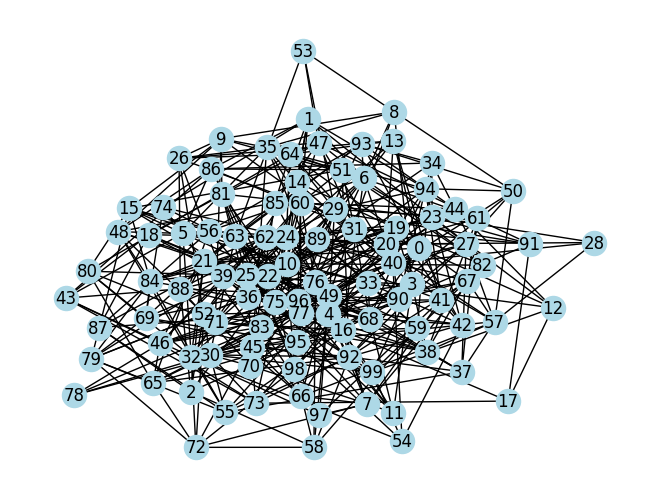

In [8]:
G = nx.Graph(graph)
nx.draw(G, with_labels=True, node_color="lightblue", node_size=300)
plt.savefig("data/graph.png")
plt.show

### Heuristics

In [9]:
Heuristic_values = data['Heuristic']
Heuristic_values

array([[  3,   2,   3,   2,   3,   3,   3,   3,   4,   3,   2,   3,   4,
          3,   3,   3,   4,   4,   3,   0,   3,   2,   4,   3,   3,   3,
          3,   2,   4,   3,   3,   2,   3,   3,   3,   3,   1,   5,   3,
          2,   3,   2,   3,   3,   4,   2,   2,   4,   3,   3,   5,   4,
          3,   5,   2,   3,   5,   3,   4,   4,   2,   4,   1,   3,   4,
          2,   4,   3,   2,   2,   2,   4,   3,   4, 100,   3,   3,   3,
          2,   2,   3,   2,   4,   3,   2,   3,   3,   2,   3,   4,   3,
          3,   3,   4,   3,   1,   1,   4,   3,   3]], dtype=uint8)

In [10]:
heuristic = Heuristic_values.flatten()
heuristic

array([  3,   2,   3,   2,   3,   3,   3,   3,   4,   3,   2,   3,   4,
         3,   3,   3,   4,   4,   3,   0,   3,   2,   4,   3,   3,   3,
         3,   2,   4,   3,   3,   2,   3,   3,   3,   3,   1,   5,   3,
         2,   3,   2,   3,   3,   4,   2,   2,   4,   3,   3,   5,   4,
         3,   5,   2,   3,   5,   3,   4,   4,   2,   4,   1,   3,   4,
         2,   4,   3,   2,   2,   2,   4,   3,   4, 100,   3,   3,   3,
         2,   2,   3,   2,   4,   3,   2,   3,   3,   2,   3,   4,   3,
         3,   3,   4,   3,   1,   1,   4,   3,   3], dtype=uint8)

# A: BFS

In [11]:
def bfs(graph, start_node, target_node):
    # Counters for complexity
    total_enqueued = 0
    max_queue_size = 0
    max_visited_size = 0
    
    if start_node not in graph or target_node not in graph:
        return None, 0, 0 # Return values in case of error

    queue = deque([(start_node, [start_node])])
    total_enqueued += 1 # First node enqueued
    
    visited = set()

    while queue:
        # Update max queue size
        max_queue_size = max(max_queue_size, len(queue))
        
        current_node, path = queue.popleft()

        if current_node == target_node :
            # Calculate final space complexity (max of queue and visited sizes)
            space_complexity = max(max_queue_size, max_visited_size)
            return path, total_enqueued, space_complexity

        if current_node not in visited:
            visited.add(current_node)
            max_visited_size = max(max_visited_size, len(visited))
            
            if current_node in graph:
                for neighbor in graph[current_node]:
                    if neighbor not in visited:
                        new_path = list(path)
                        new_path.append(neighbor)
                        queue.append((neighbor, new_path))
                        total_enqueued += 1 # New node enqueued
    
    space_complexity = max(max_queue_size, max_visited_size)
    return None, total_enqueued, space_complexity

In [12]:
start_node = 0
target_node = 19

path, time_comp, space_comp = bfs(graph, 0, 19)

if path:
    print(f'the path {path} is found from {start_node} to {target_node}')
    print(f"Time Complexity (Total nodes enqueued): {time_comp}")
    print(f"Space Complexity (Max size of queue or visited): {space_comp}")
else:
    print(f'the path is not found from {start_node} to {target_node}')



the path [0, 21, 36, 19] is found from 0 to 19
Time Complexity (Total nodes enqueued): 204
Space Complexity (Max size of queue or visited): 134


# B: DFS

In [13]:
def dfs(graph, start_node, target_node):
    # Search queue: in iterative DFS, this is the stack
    search_stack = [(start_node, [start_node])]  # Each element: (node, path to this node)

    visited = set()

    # Counters
    total_enqueued = 0          # Total number of nodes added to the search queue (stack)
    max_search_size = 0         # Maximum size of the search queue (stack)
    max_visited_size = 0        # Maximum size of the visited set

    # Initially, push the start_node onto the stack
    total_enqueued += 1
    max_search_size = max(max_search_size, len(search_stack))

    while search_stack:
        # DFS works in LIFO order
        current_node, path = search_stack.pop()

        if current_node in visited:
            continue

        visited.add(current_node)
        max_visited_size = max(max_visited_size, len(visited))

        # If the target node is found, calculate metrics and return
        if current_node == target_node:
            space_complexity = max(max_search_size, max_visited_size)
            return path, total_enqueued, space_complexity

        # Push neighbors onto the stack
        # To maintain a standard DFS order, push them in reverse
        if current_node in graph:
            neighbors = graph[current_node]
            for neighbor in reversed(neighbors):
                if neighbor not in visited:
                    search_stack.append((neighbor, path + [neighbor]))
                    total_enqueued += 1
                    max_search_size = max(max_search_size, len(search_stack))

    # If the target node is not found
    space_complexity = max(max_search_size, max_visited_size)
    return None, total_enqueued, space_complexity


In [14]:
path, time_comp, space_comp = dfs(graph, 0, 19)

if path:
    print(f'the path {path} is found from {start_node} to {target_node}')
    print(f"Time Complexity (Total nodes enqueued): {time_comp}")
    print(f"Space Complexity (Max size of queue or visited): {space_comp}")
else:
    print(f'the path is not found from {start_node} to {target_node}')

the path [0, 4, 29, 10, 2, 21, 32, 43, 18, 47, 35, 5, 33, 12, 17, 73, 25, 22, 24, 13, 41, 62, 19] is found from 0 to 19
Time Complexity (Total nodes enqueued): 104
Space Complexity (Max size of queue or visited): 82


# C: Best First Search

In [15]:
def best_first_search(graph, heuristic, start, goal):
    # Counters
    total_pushed_pq = 0
    max_pq_size = 0
    max_visited_size = 0

    # Priority queue stores tuples: (heuristic_value, node, path)
    # Initialize with the start node
    pq = [(heuristic[start], start, [start])]
    total_pushed_pq += 1
    max_pq_size = 1 # Initial size

    visited = set()

    while pq:
        # Update max PQ size before popping
        max_pq_size = max(max_pq_size, len(pq))
        
        # Pop the node with the lowest heuristic value
        h, node, path = heapq.heappop(pq)

        # If we've already visited this node with a potentially better path, skip it
        if node in visited:
            continue
        
        # Mark node as visited and update max visited size
        visited.add(node)
        max_visited_size = max(max_visited_size, len(visited))

        # Goal check
        if node == goal:
            # Calculate final space complexity
            space_complexity = max(max_pq_size, max_visited_size)
            return path, total_pushed_pq, space_complexity

        # Expand neighbors
        if node in graph: # Ensure node exists in graph keys
            for neighbor in graph[node]:
                if neighbor not in visited:
                    new_path = path + [neighbor]
                    heapq.heappush(pq, (heuristic[neighbor], neighbor, new_path))
                    total_pushed_pq += 1
                    # Update max_pq_size after pushing
                    max_pq_size = max(max_pq_size, len(pq))


    # If goal is not reached
    space_complexity = max(max_pq_size, max_visited_size)
    return None, total_pushed_pq, space_complexity


In [16]:
start_node = 0
target_node = 19

path, time_comp, space_comp = best_first_search(graph, heuristic, 0, 19)


if path:
    print(f'the path {path} is found from {start_node} to {target_node}')
    print(f"Time Complexity (Total nodes enqueued): {time_comp}")
    print(f"Space Complexity (Max size of queue or visited): {space_comp}")
else:
    print(f'the path is not found from {start_node} to {target_node}')

the path [0, 21, 36, 19] is found from 0 to 19
Time Complexity (Total nodes enqueued): 14
Space Complexity (Max size of queue or visited): 11


# D: IDS

In [17]:
def ids(graph, start, goal):

    time_counter = 0
    max_q_size = 0
    max_visited_size = 0

    depth = 0

    while True:

        Q = [(start, [start], 0)]
        visited = set([start])

        time_counter += 1
        max_q_size = max(max_q_size, len(Q))
        max_visited_size = max(max_visited_size, len(visited))

        while Q:

            node, path, d = Q.pop()

            if node == goal:
                space_complexity = max(max_q_size, max_visited_size)
                return path, time_counter, space_complexity

            if d < depth:
                for neighbor in graph[node]:

                    if neighbor not in visited:
                        visited.add(neighbor)
                        Q.append((neighbor, path + [neighbor], d + 1))

                        time_counter += 1

                        max_q_size = max(max_q_size, len(Q))
                        max_visited_size = max(max_visited_size, len(visited))

        depth += 1


In [18]:
start_node = 0
target_node = 19

final_path, time_complexity_ids, space_complexity_ids = ids(graph, start_node, target_node)

if final_path:
    print(f"Path found: {' -> '.join(map(str, final_path))}")
    print(f"Time Complexity : {time_complexity_ids}")
    print(f"Space Complexity : {space_complexity_ids}")
else:
    print(f"\nGoal {target_node} not found.")
    print(f"Total nodes visited across all DLS attempts: {time_complexity_ids}")
    print(f"Maximum recursion depth reached: {space_complexity_ids}")


Path found: 0 -> 68 -> 36 -> 19
Time Complexity : 80
Space Complexity : 42


# E: All Algorithms Without Visited List

## BFS Without Visited List

In [19]:
def bfs_without_visited(graph, start_node, target_node, max_depth):
    # Counters for time and space complexity
    total_enqueued = 0
    max_queue_size = 0

    # Check if start or target nodes are not in the graph
    if start_node not in graph or target_node not in graph:
        return None, None, total_enqueued, max_queue_size

    # Initialize the queue with the start node, its path, and depth
    # Queue stores tuples: (current_node, path_to_current_node, depth)
    queue = deque([(start_node, [start_node], 0)])
    total_enqueued += 1
    max_queue_size = max(max_queue_size, len(queue))

    while queue:
        current_node, path, depth = queue.popleft()

        # Target node found
        if current_node == target_node:
            # No need to update counters here as the algorithm has finished
            return path, depth, total_enqueued, max_queue_size

        # Stop exploring if maximum depth is reached
        if depth >= max_depth:
            continue

        # Explore neighbors
        if current_node in graph: # Ensure the current node has defined neighbors
            for neighbor in graph[current_node]:
                # Key difference: No check if 'neighbor' has been visited.
                new_path = list(path) # Create a new list for the path
                new_path.append(neighbor)
                queue.append((neighbor, new_path, depth + 1))
                total_enqueued += 1 # Increment for each node enqueued
                max_queue_size = max(max_queue_size, len(queue)) # Update max queue size

    # Path not found within the given max_depth or graph constraints
    return None, None, total_enqueued, max_queue_size

In [20]:
start_node = 0
target_node = 19 
max_depth = 99 

# Call the function
path, depth, enqueued_count, max_size = bfs_without_visited(graph, start_node, target_node, max_depth)

# Report results
if path:
    print(f"Path found: {path}")
    print(f"Path depth: {depth}")
    print(f" Time Complexity Proxy: {enqueued_count}")
    print(f"Space Complexity Proxy: {max_size}")
else:
    print("Path not found.")
    print(f"Total nodes enqueued (Time Complexity Proxy): {enqueued_count}")
    print(f"Maximum queue size (Space Complexity Proxy): {max_size}")


Path found: [0, 21, 36, 19]
Path depth: 3
 Time Complexity Proxy: 379
Space Complexity Proxy: 302


## DFS Without Visited List

In [21]:
def dfs_without_visited(graph, start_node, target_node, max_depth):
    # stack elements: (node, path, depth)
    search_stack = [(start_node, [start_node], 0)]

    # Counters
    total_enqueued = 0
    max_search_size = 0

    total_enqueued += 1
    max_search_size = max(max_search_size, len(search_stack))

    while search_stack:
        current_node, path, depth = search_stack.pop()

        # check goal
        if current_node == target_node:
            space_complexity = max_search_size
            return path, depth, total_enqueued, space_complexity

        # expand if depth limit not reached
        if depth < max_depth and current_node in graph:
            neighbors = graph[current_node]

            for neighbor in reversed(neighbors):
                search_stack.append((neighbor, path + [neighbor], depth + 1))
                total_enqueued += 1
                max_search_size = max(max_search_size, len(search_stack))

    space_complexity = max_search_size
    return None, None, total_enqueued, space_complexity


In [22]:
start_node = 0
target_node = 19 
max_depth = 99 
path, depth, time_comp, space_comp = dfs_without_visited(graph, start_node, target_node, max_depth)
if path:
    print("Path found:", path)
    print("Depth:", depth)
else:
    print("No path found.")

print("Time complexity:", time_comp)
print("Space complexity:", space_comp)


Path found: [0, 4, 29, 10, 2, 21, 32, 43, 18, 4, 29, 10, 2, 21, 32, 43, 18, 4, 29, 10, 2, 21, 32, 43, 18, 4, 29, 10, 2, 21, 32, 43, 18, 4, 29, 10, 2, 21, 32, 43, 18, 4, 29, 10, 2, 21, 32, 43, 18, 4, 29, 10, 2, 21, 32, 43, 18, 4, 29, 10, 2, 21, 32, 43, 18, 4, 29, 10, 2, 21, 32, 43, 18, 4, 29, 10, 2, 21, 32, 43, 18, 4, 29, 10, 2, 21, 32, 43, 18, 4, 29, 10, 2, 21, 32, 43, 18, 87, 62, 19]
Depth: 99
Time complexity: 660
Space complexity: 496


## Best First Search Without Visited List

In [23]:
def best_first_search_no_visited(graph, heuristic, start, goal, max_depth):
    # Counters
    total_pushed_pq = 0
    max_pq_size = 0

    # Priority queue stores tuples: (heuristic_value, node, path, current_depth)
    # Initialize with the start node at depth 0
    pq = [(heuristic[start], start, [start], 0)]
    total_pushed_pq += 1
    max_pq_size = 1

    while pq:
        # Update max PQ size before popping
        max_pq_size = max(max_pq_size, len(pq))
        
        # Pop the node with the lowest heuristic value
        h, node, path, depth = heapq.heappop(pq)

        # Goal check
        if node == goal:
            return path, depth, total_pushed_pq, max_pq_size, 

        # Expand neighbors only if we haven't reached the max_depth
        if depth < max_depth:
            if node in graph: # Ensure node exists in graph keys
                for neighbor in graph[node]:
                    new_path = path + [neighbor]
                    new_depth = depth + 1
                    
                    heapq.heappush(pq, (heuristic[neighbor], neighbor, new_path, new_depth))
                    total_pushed_pq += 1
                    
                    # Update max_pq_size after pushing
                    max_pq_size = max(max_pq_size, len(pq))

    # If goal is not reached or search space exhausted within max_depth
    return None, None, total_pushed_pq, max_pq_size


In [24]:
start_node = 0
target_node = 19 # A node defined in the example graph
max_depth = 99 # Set max_depth to observe its effect

path, depth, time_comp, space_comp = best_first_search_no_visited(graph, heuristic, start_node, target_node, max_depth)

if path:
    print("Path:", path)
    print("Depth:", depth)
else:
    print("Path not found")

print("Time complexity:", time_comp)
print("Space complexity:", space_comp)


Path: [0, 21, 36, 19]
Depth: 3
Time complexity: 14
Space complexity: 11


## IDS Without Visited List

In [25]:
def ids_no_visited(graph, start, goal, max_depth):

    time_counter = 0
    max_q_size = 0

    depth = 0

    while depth <= max_depth:

        Q = [(start, [start], 0)]

        time_counter += 1
        max_q_size = max(max_q_size, len(Q))

        while Q:

            node, path, d = Q.pop()

            if node == goal:
                space_complexity = max_q_size
                return path,d, time_counter, space_complexity

            if d < depth:
                for neighbor in graph[node]:

                    Q.append((neighbor, path + [neighbor], d + 1))

                    time_counter += 1
                    max_q_size = max(max_q_size, len(Q))

        depth += 1

    return None,None, time_counter, max_q_size, 

In [26]:
start_node = 0
target_node = 19
max_depth_limit = 99 

result_path, depth, time_comp, space_comp  = ids_no_visited(graph, start_node, target_node, max_depth = max_depth_limit)

if result_path:
    print(f"Goal {target_node} found at depth {depth}!")
    print("Path:", " -> ".join(map(str, result_path)))
    print("\n--- Complexity Analysis ---")
    print(f"Time Complexity: {time_comp}")
    print(f"Space Complexity: {space_comp}")
else:
    print("\nSearch failed to find the target node.")


Goal 19 found at depth 3!
Path: 0 -> 68 -> 36 -> 19

--- Complexity Analysis ---
Time Complexity: 90
Space Complexity: 14


# F: Defining Main Function

In [27]:
def main_func(start_node, target_node, graph, algorithm , heuristic, max_depth) : 

    if algorithm == bfs:
        path, time_comp, space_comp = bfs(graph, start_node, target_node)
        
        if path:
            print(f'---The algorithm BFS with visited list---')
            print(f'the path {path} is found from {start_node} to {target_node}')
            print(f"Time Complexity (Total nodes enqueued): {time_comp}")
            print(f"Space Complexity (Max size of queue or visited): {space_comp}")
            return path, time_comp, space_comp
        
        else:
            print(f'the path is not found from {start_node} to {target_node}')


    elif algorithm == dfs:
        path, time_comp, space_comp = dfs(graph, start_node, target_node)
       
        if path:
            print(f'---The algorithm DFS with visited list---')
            print(f'the path {path} is found from {start_node} to {target_node}')
            print(f"Time Complexity (Total nodes enqueued): {time_comp}")
            print(f"Space Complexity (Max size of queue or visited): {space_comp}")
            return path, time_comp, space_comp

        else:
            print(f'the path is not found from {start_node} to {target_node}')

    elif algorithm == best_first_search:
        path, time_comp, space_comp = best_first_search(graph, heuristic,start_node, target_node )
        if path:
            print(f'---The algorithm best_first_search with visited list---')
            print(f'the path {path} is found from {start_node} to {target_node}')
            print(f"Time Complexity (Total nodes enqueued): {time_comp}")
            print(f"Space Complexity (Max size of queue or visited): {space_comp}")
            return path, time_comp, space_comp

        else:
            print(f'the path is not found from {start_node} to {target_node}')


    elif algorithm == ids:
        path, time_comp, space_comp = ids(graph, start_node, target_node)
       
        if path:
            print(f'---The algorithm ids with visited list---')
            print(f'the path {path} is found from {start_node} to {target_node}')
            print(f"Time Complexity (Total nodes enqueued): {time_comp}")
            print(f"Space Complexity (Max size of queue or visited): {space_comp}")
            return path, time_comp, space_comp

        else:
            print(f'the path is not found from {start_node} to {target_node}')


    elif algorithm == bfs_without_visited:
        path,depth, time_comp, space_comp = bfs_without_visited(graph, start_node, target_node,max_depth) 
         
        if path:
            print(f'---The algorithm BFS without visited list with maximum depth of 99 ---')
            print(f'the path {path} is found from {start_node} to {target_node} at depth{depth}')
            print(f"Time Complexity (Total nodes enqueued): {time_comp}")
            print(f"Space Complexity (Max size of queue): {space_comp}")
            return path, time_comp, space_comp

        else:
         print(f'the path is not found from {start_node} to {target_node}')
         
    elif algorithm == dfs_without_visited:
        path,depth, time_comp, space_comp = dfs_without_visited(graph, start_node, target_node,max_depth) 
         
        if path:
            print(f'---The algorithm DFS without visited list with maximum depth of 99 ---')
            print(f'the path {path} is found from {start_node} to {target_node} at depth{depth}')
            print(f"Time Complexity (Total nodes enqueued): {time_comp}")
            print(f"Space Complexity (Max size of queue): {space_comp}")
            return path, time_comp, space_comp

        else:
         print(f'the path is not found from {start_node} to {target_node}')
         


    elif algorithm == best_first_search_no_visited:
        path, depth, time_comp, space_comp = best_first_search_no_visited(graph, heuristic, start_node, target_node, max_depth )
        
        if path:
            print(f'---The algorithm Best first search without visited list with maximum depth of 99 ---')
            print(f'the path {path} is found from {start_node} to {target_node} at depth{depth}')
            print(f"Time Complexity (Total nodes enqueued): {time_comp}")
            print(f"Space Complexity (Max size of queue): {space_comp}")
            return path, time_comp, space_comp

        else:
            print(f'the path is not found from {start_node} to {target_node}')
         
        
    elif algorithm == ids_no_visited:
        path, depth, time_comp, space_comp = ids_no_visited(graph, start_node, target_node,max_depth) 

         
        if path:
            print(f'---The algorithm IDS without visited list with maximum depth of 99 ---')
            print(f'the path {path} is found from {start_node} to {target_node} at depth{depth}')
            print(f"Time Complexity (Total nodes enqueued): {time_comp}")
            print(f"Space Complexity (Max size of queue): {space_comp}")
            return path, time_comp, space_comp

        else:
            print(f'the path is not found from {start_node} to {target_node}')

## Report All Results

In [28]:
_ , time_bfs, space_bfs = main_func(start_node= 0, target_node= 19, graph= graph, algorithm = bfs, heuristic = None , max_depth= None )
_ , time_dfs, space_dfs = main_func(start_node= 0, target_node= 19, graph= graph, algorithm = dfs, heuristic = None , max_depth= None )
_ , time_best_first_search, space_best_first_search = main_func(start_node= 0, target_node= 19, graph= graph, algorithm = best_first_search, heuristic = heuristic , max_depth= None )
_ , time_ids, space_ids = main_func(start_node= 0, target_node= 19, graph= graph, algorithm = ids, heuristic = None , max_depth= None )

---The algorithm BFS with visited list---
the path [0, 21, 36, 19] is found from 0 to 19
Time Complexity (Total nodes enqueued): 204
Space Complexity (Max size of queue or visited): 134
---The algorithm DFS with visited list---
the path [0, 4, 29, 10, 2, 21, 32, 43, 18, 47, 35, 5, 33, 12, 17, 73, 25, 22, 24, 13, 41, 62, 19] is found from 0 to 19
Time Complexity (Total nodes enqueued): 104
Space Complexity (Max size of queue or visited): 82
---The algorithm best_first_search with visited list---
the path [0, 21, 36, 19] is found from 0 to 19
Time Complexity (Total nodes enqueued): 14
Space Complexity (Max size of queue or visited): 11
---The algorithm ids with visited list---
the path [0, 68, 36, 19] is found from 0 to 19
Time Complexity (Total nodes enqueued): 80
Space Complexity (Max size of queue or visited): 42


In [29]:
  #NV is short for not visited
_ , time_bfs_NV, space_bfs_NV = main_func(start_node= 0, target_node= 19, graph= graph, algorithm = bfs_without_visited, heuristic = None , max_depth= 99 )
_ , time_dfs_NV, space_dfs_NV = main_func(start_node= 0, target_node= 19, graph= graph, algorithm = dfs_without_visited, heuristic = None , max_depth= 99 )
_ , time_best_first_search_NV, space_best_first_search_NV = main_func(start_node= 0, target_node= 19, graph= graph, algorithm = best_first_search_no_visited, heuristic = heuristic , max_depth= 99 )
_ , time_ids_NV, space_ids_NV = main_func(start_node= 0, target_node= 19, graph= graph, algorithm = ids_no_visited, heuristic = None , max_depth= 99 )

---The algorithm BFS without visited list with maximum depth of 99 ---
the path [0, 21, 36, 19] is found from 0 to 19 at depth3
Time Complexity (Total nodes enqueued): 379
Space Complexity (Max size of queue): 302
---The algorithm DFS without visited list with maximum depth of 99 ---
the path [0, 4, 29, 10, 2, 21, 32, 43, 18, 4, 29, 10, 2, 21, 32, 43, 18, 4, 29, 10, 2, 21, 32, 43, 18, 4, 29, 10, 2, 21, 32, 43, 18, 4, 29, 10, 2, 21, 32, 43, 18, 4, 29, 10, 2, 21, 32, 43, 18, 4, 29, 10, 2, 21, 32, 43, 18, 4, 29, 10, 2, 21, 32, 43, 18, 4, 29, 10, 2, 21, 32, 43, 18, 4, 29, 10, 2, 21, 32, 43, 18, 4, 29, 10, 2, 21, 32, 43, 18, 4, 29, 10, 2, 21, 32, 43, 18, 87, 62, 19] is found from 0 to 19 at depth99
Time Complexity (Total nodes enqueued): 660
Space Complexity (Max size of queue): 496
---The algorithm Best first search without visited list with maximum depth of 99 ---
the path [0, 21, 36, 19] is found from 0 to 19 at depth3
Time Complexity (Total nodes enqueued): 14
Space Complexity (Max size

# G: Time And Space Complexity Comparison Table

In [30]:
data = [
    {"Algorithm": "BFS", "Time Complexity": time_bfs, "Space Complexity": space_bfs},
    {"Algorithm": "DFS", "Time Complexity": time_dfs, "Space Complexity": space_dfs},
    {"Algorithm": "Best-First Search", "Time Complexity": time_best_first_search, "Space Complexity": space_best_first_search},
    {"Algorithm": "IDS", "Time Complexity": time_ids, "Space Complexity": space_ids},
    {"Algorithm": "BFS (No Visited)", "Time Complexity": time_bfs_NV, "Space Complexity": space_bfs_NV},
    {"Algorithm": "DFS (No Visited)", "Time Complexity": time_dfs_NV, "Space Complexity": space_dfs_NV},
    {"Algorithm": "Best-First Search (No Visited)", "Time Complexity": time_best_first_search_NV, "Space Complexity": space_best_first_search_NV},
    {"Algorithm": "IDS (No Visited)", "Time Complexity": time_ids_NV, "Space Complexity": space_ids_NV},
]

df = pd.DataFrame(data)
df


,Algorithm,Time Complexity,Space Complexity
0,BFS,204,134
1,DFS,104,82
2,Best-First Search,14,11
3,IDS,80,42
4,BFS (No Visited),379,302
5,DFS (No Visited),660,496
6,Best-First Search (No Visited),14,11
7,IDS (No Visited),90,14


In [31]:
df.to_csv("data/Time And Space Complexity Comparison.csv", index=False, encoding='utf-8-sig')

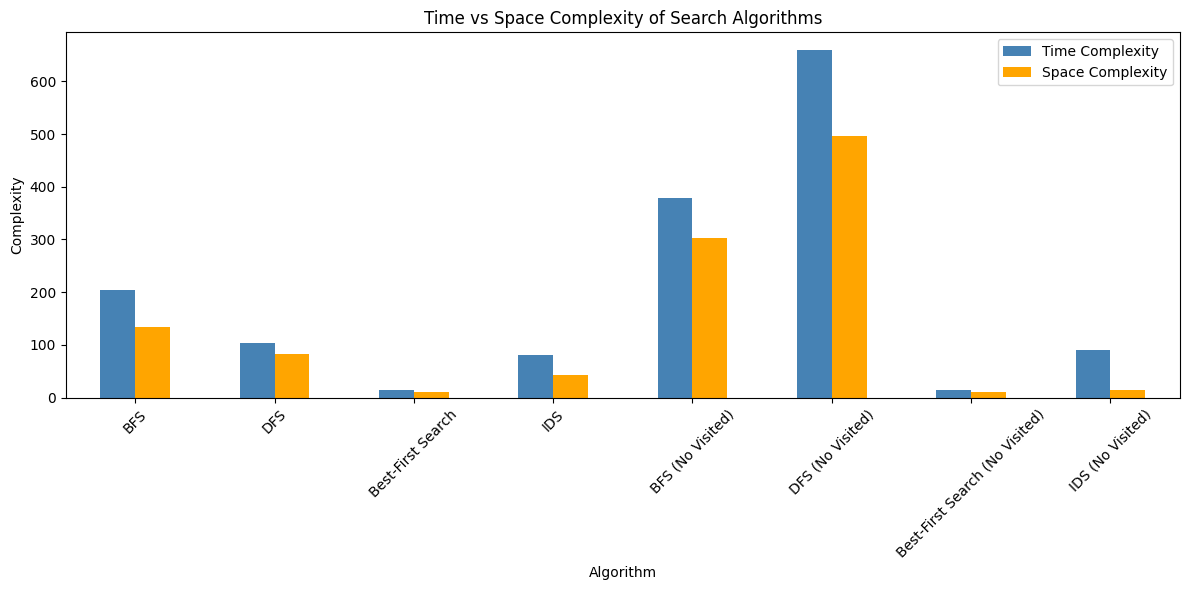

In [32]:
ax = df.plot(
    x="Algorithm",
    y=["Time Complexity", "Space Complexity"],
    kind="bar",
    figsize=(12,6),
    color=["steelblue", "orange"]   # رنگ‌های متفاوت
)

plt.ylabel("Complexity")
plt.title("Time vs Space Complexity of Search Algorithms")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig("data/comparison_plot")
plt.show()